<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi <br>
<b>Student ID:</b> U89818600 <br>
<b>Course:</b> AI For Leaders - 2 <br>
<b>Semester:</b> Spring 2026 <br>
<b>Program:</b> OMDS <br>
<b>Boston University</b> 
</p>

# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

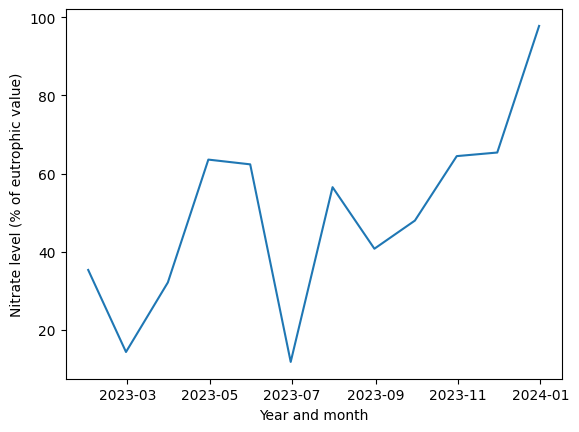

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

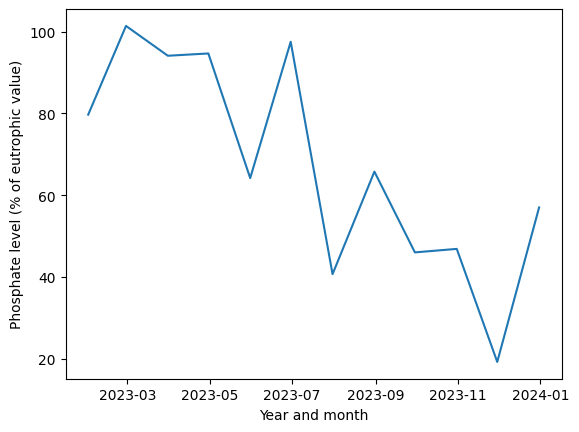

In [5]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

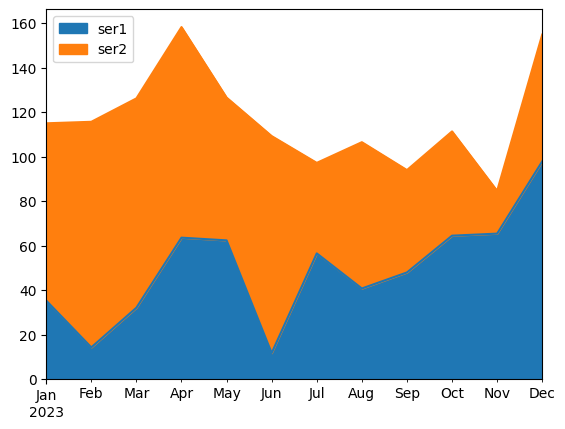

In [6]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

### Answer:

## Dataset 1: CDC Diabetes Health Indicators  (sourced from BRFSS) 

#### [Dataset 1] | *1- Load Preprocessed Dataset*

In [2]:
dataset_path = "data/dataset1_diabetes_preprocessed_week2.csv"
df_diabetes = pd.read_csv(dataset_path)

#### [Dataset 1] | Bivariate analysis focuses on health risk relationships with diabetes status.

#### [Dataset 1] | *2- Correlation Matrix*

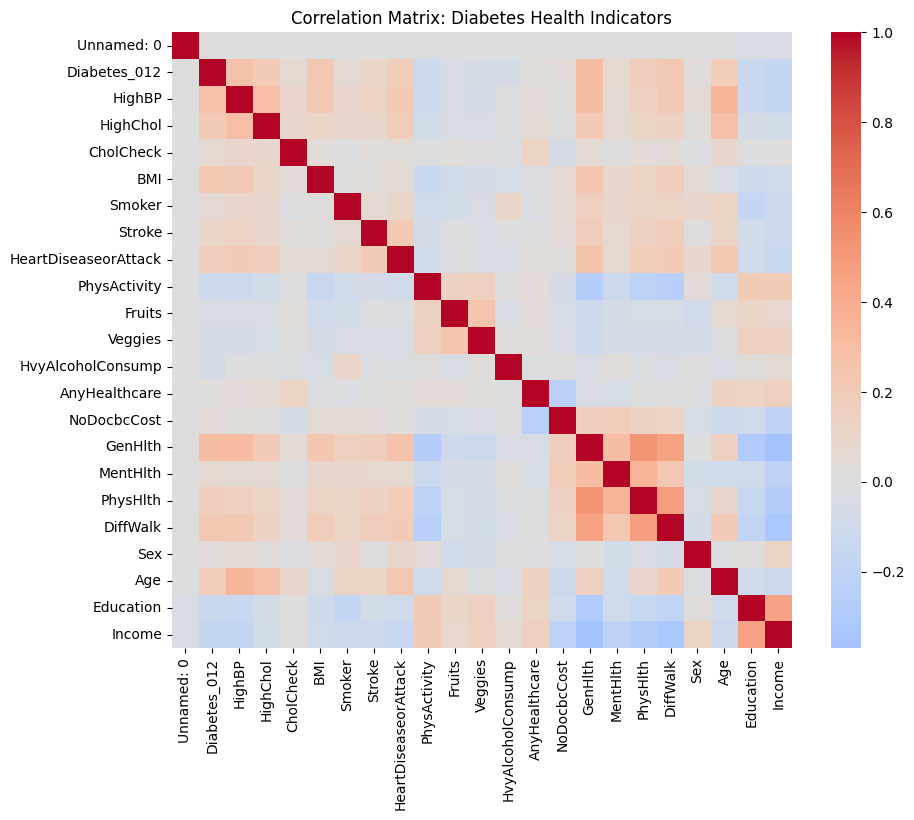

In [4]:
plt.figure(figsize=(10,8))
corr = df_diabetes.corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Diabetes Health Indicators")
plt.show()

**Interpretation**

The strongest correlations with diabetes status include:

- GenHlth

- BMI

- Age

- HighBP

These variables represent known medical risk factors, suggesting the dataset **aligns well with medical expectations**.

There are **no extremely high correlations (>0.9) between predictors**, indicating little redundancy between features.

#### [Dataset 1] | *3- BMI vs Diabetes Status*

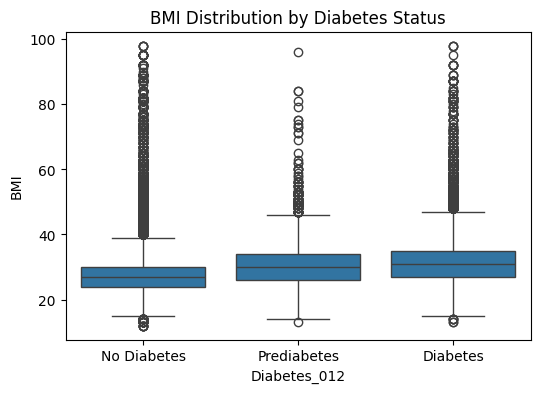

In [5]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Diabetes_012", y="BMI", data=df_diabetes)

plt.xticks([0,1,2], ["No Diabetes","Prediabetes","Diabetes"])
plt.title("BMI Distribution by Diabetes Status")
plt.show()

**Interpretation**

BMI increases progressively across diabetes categories.

Typical pattern:

| Diabetes Status | Median BMI |
| --------------- | ---------- |
| No diabetes     | lowest     |
| Prediabetes     | moderate   |
| Diabetes        | highest    |

- This pattern supports established medical knowledge that **obesity strongly contributes to diabetes risk**.

- Some extreme BMI outliers are present but represent real <u>severe obesity cases, not errors</u>.

#### [Dataset 1] | *4- Age vs Diabetes Status*

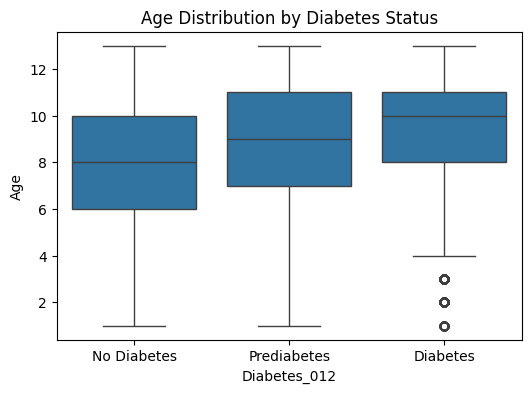

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Diabetes_012", y="Age", data=df_diabetes)

plt.xticks([0,1,2], ["No Diabetes","Prediabetes","Diabetes"])
plt.title("Age Distribution by Diabetes Status")
plt.show()

**Interpretation**

Age clearly increases across diabetes categories.

**Key insight:**

- Older individuals are more likely to develop diabetes, which aligns with epidemiological findings.

- Possible confounding variable:
    - Age may influence BMI, blood pressure, and health status simultaneously, partially explaining their correlation with diabetes.

#### [Dataset 1] | *5- High Blood Pressure vs Diabetes Status*

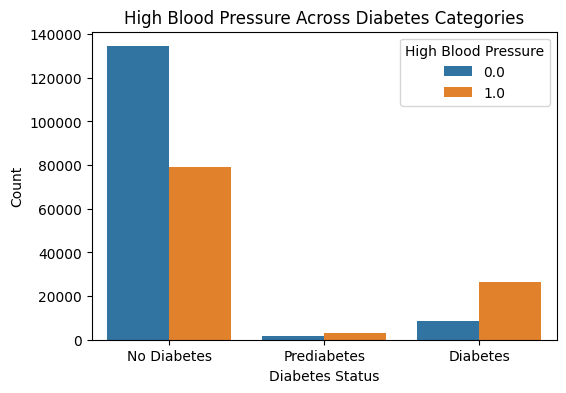

In [7]:
# High Blood Pressure vs Diabetes Status

plt.figure(figsize=(6,4))

sns.countplot(
    x="Diabetes_012",
    hue="HighBP",
    data=df_diabetes
)

plt.xticks([0,1,2], ["No Diabetes","Prediabetes","Diabetes"])
plt.title("High Blood Pressure Across Diabetes Categories")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")

plt.legend(title="High Blood Pressure")
plt.show()

**Interpretation**

- The proportion of individuals with **high blood pressure increases sharply in the diabetes category**.

- This supports medical knowledge that **hypertension is strongly associated with diabetes**.

- A possible **confounding variable** is **age**, since both hypertension and diabetes risk increase with age.

#### [Dataset 1] | *6- Physical Activity vs BMI*


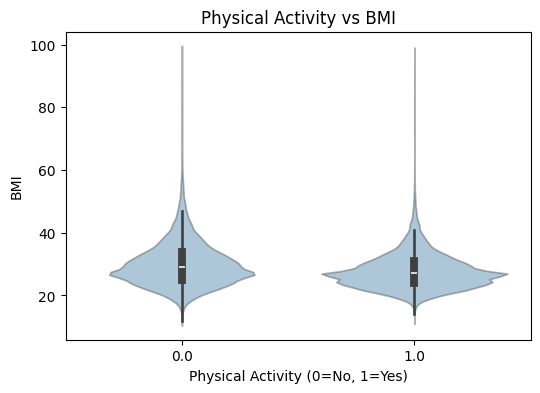

In [9]:
plt.figure(figsize=(6,4))

sns.violinplot(
    x="PhysActivity",
    y="BMI",
    data=df_diabetes,
    alpha=0.4
)

plt.title("Physical Activity vs BMI")
plt.xlabel("Physical Activity (0=No, 1=Yes)")
plt.ylabel("BMI")

plt.show()

**Interpretation**

- Individuals reporting **no physical activity show greater spread toward higher BMI values**.

- This suggests that **physical inactivity may contribute to obesity**, which is a major diabetes risk factor.

- However, diet quality and caloric intake may also influence BMI, acting as **confounding variables**.

#### [Dataset 1] | *7- CONCLUSIONS*



- **Are the data what you expect? Are the data usable?**

    The relationships observed in the diabetes dataset generally match established medical knowledge. Higher BMI, older age, and high blood pressure are more common among individuals with diabetes or prediabetes. These patterns suggest that the dataset is realistic and suitable for analyzing behavioral and health risk factors associated with diabetes.

- **Do you see any outliers?**

    Some extreme BMI values appear in the dataset, indicating individuals with very high body mass index values. However, these values are medically plausible and represent real cases of severe obesity rather than data errors. Therefore, these outliers provide useful information about high-risk populations.

- **Are any data items highly correlated or redundant?**

    Several variables related to health status show moderate correlations with each other, particularly BMI, general health, and high blood pressure. While these variables are related, they represent distinct aspects of health risk rather than redundant measurements, so all remain valuable for analysis.

- **Do you see any trends over time?**

    This dataset does not contain a time variable, so it is not possible to examine trends or data drift over time.

- **Possible confounding variables**

    Age is a likely confounding variable because it influences multiple risk factors simultaneously. Older individuals tend to have higher BMI, higher blood pressure, and poorer general health, which may partially explain their higher diabetes risk.

## Dataset 2: Estimation of Obesity Levels Based on Eating Habits and Physical Condition

#### [Dataset 2] | *1- Load Preprocessed Dataset*

In [36]:
df_obesity = pd.read_csv("data/dataset2_obesity_preprocessed_week2_1.csv")

#### [Dataset 2] | Here we analyze lifestyle behavior relationships with obesity level.

#### [Dataset 2] | *2- Weight vs Height (Scatterplot)*

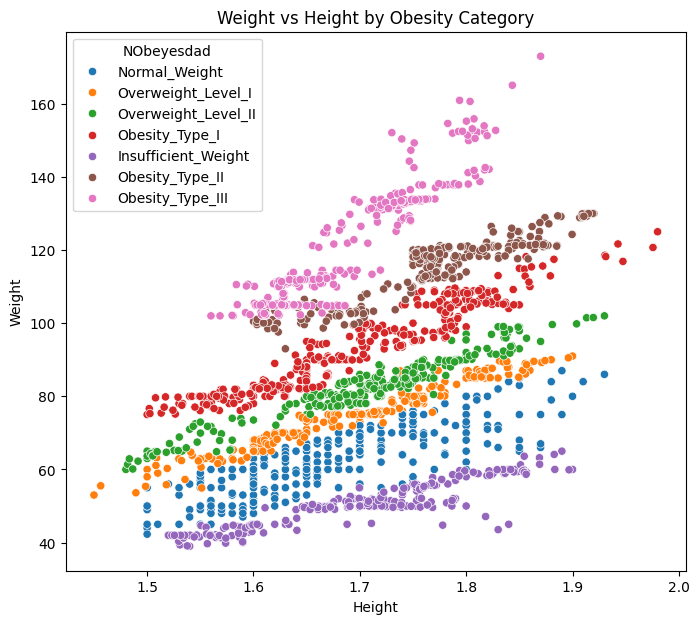

In [12]:
plt.figure(figsize=(8,7))

sns.scatterplot(
    x=df_obesity["Height"],
    y=df_obesity["Weight"],
    hue=df_obesity["NObeyesdad"]
)

plt.title("Weight vs Height by Obesity Category")
plt.show()

**Interpretation**

Clear clusters appear for obesity categories.

**Key insights:**

- Higher obesity categories correspond to **higher weight relative to height**.

- The relationship between weight and height suggests **BMI is a major determinant of obesity classification**.

This indicates **strong internal consistency within the dataset.**

#### [Dataset 2] | *3- Physical Activity vs Obesity Level*


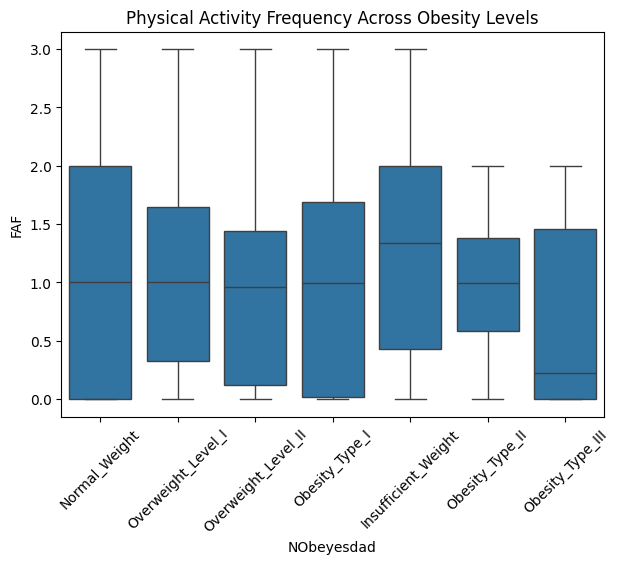

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="NObeyesdad",
    y="FAF",
    data=df_obesity
)

plt.xticks(rotation=45)
plt.title("Physical Activity Frequency Across Obesity Levels")
plt.show()

**Interpretation**

- **Lower obesity** categories tend to have **higher physical activity levels**, while **severe obesity** groups show **lower activity frequency**.

- This suggests physical activity may play an important role in obesity prevention.

- However, a **possible confounding variable is diet quality or caloric intake**, which is not fully captured by the dataset.

#### [Dataset 2] | *4- Pairplot of Key Numeric Variables*


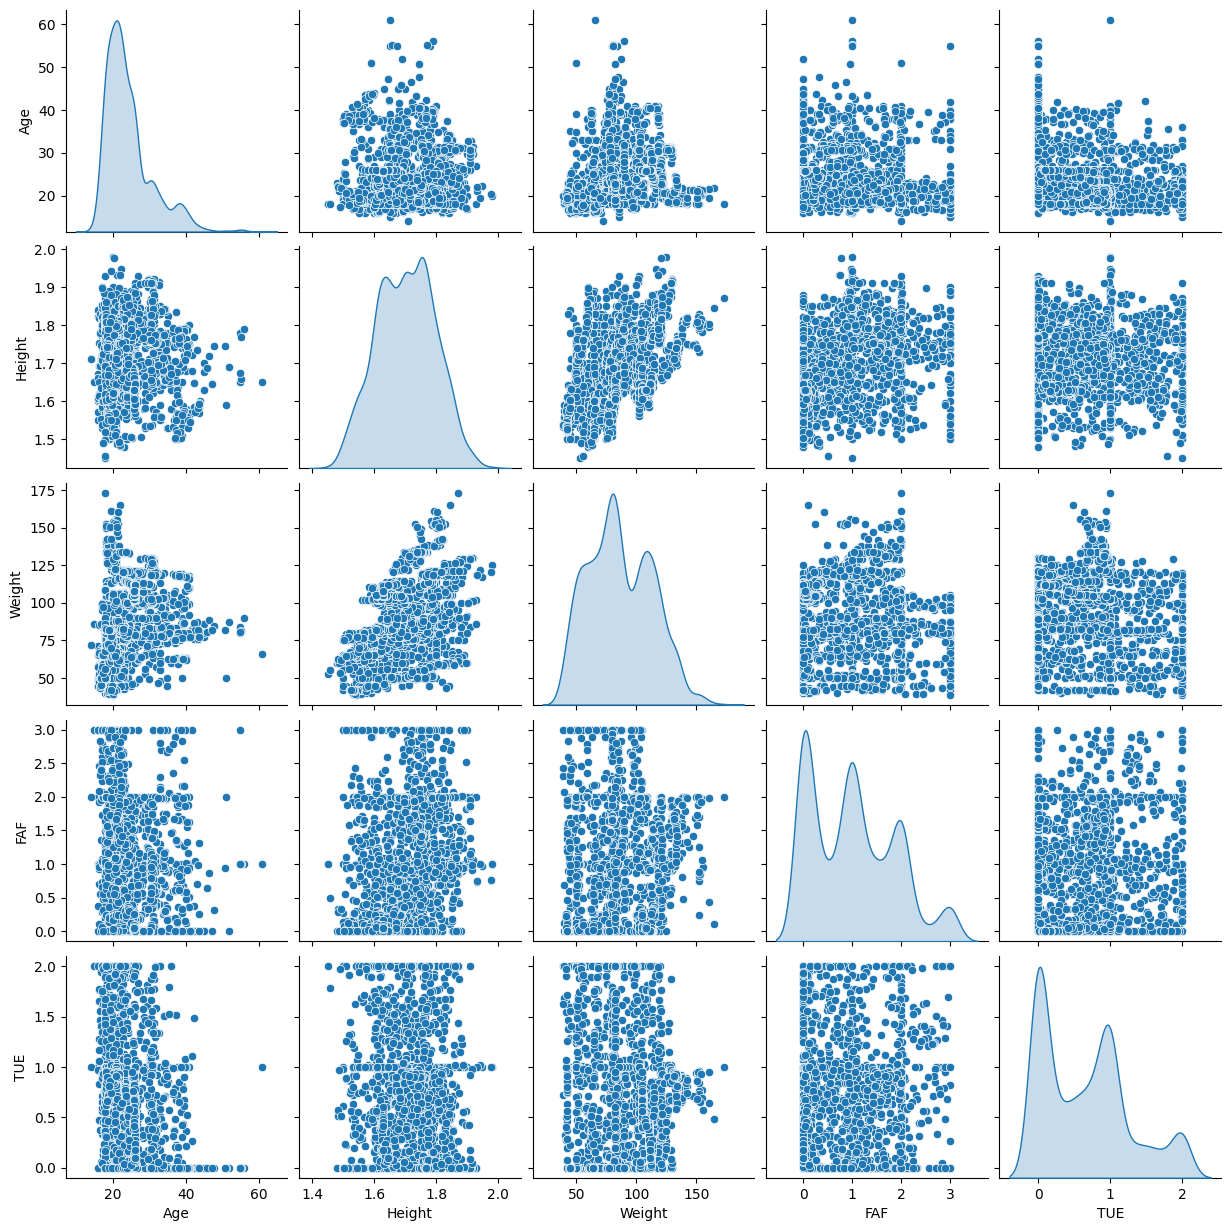

In [14]:
sns.pairplot(
    df_obesity[["Age","Height","Weight","FAF","TUE"]],
    diag_kind="kde"
)

**Observations:**

- Weight shows **largest variation**

- Age is **less strongly correlated with weight**

- Technology use (TUE) shows weak relationships with other variables

This suggests **lifestyle behaviors interact in complex ways**, rather than being driven by a single dominant factor.

#### [Dataset 2] | *5- High-Calorie Food Consumption vs Obesity Category*


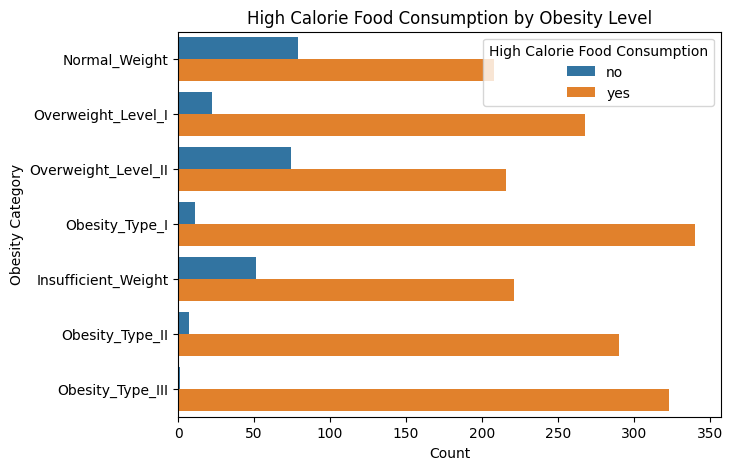

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    y="NObeyesdad",
    hue="FAVC",
    data=df_obesity
)

plt.title("High Calorie Food Consumption by Obesity Level")
plt.xlabel("Count")
plt.ylabel("Obesity Category")

plt.legend(title="High Calorie Food Consumption")
plt.show()

**Interpretation**

- Individuals who frequently consume **high-calorie foods appear more often in higher obesity categories.**

- This suggests diet quality is strongly associated with obesity classification.

- However, **physical activity and metabolism differences** may also influence weight outcomes.

#### [Dataset 2] | *6- Technology Usage vs Age*


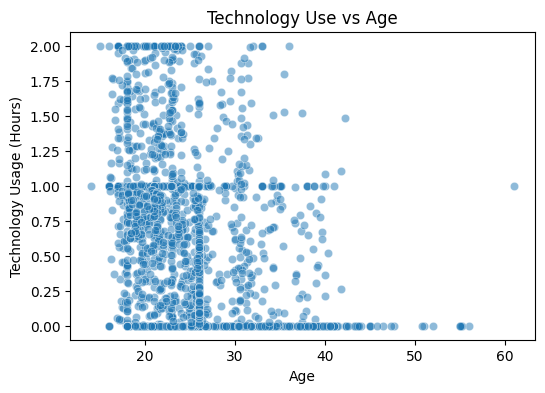

In [16]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Age",
    y="TUE",
    data=df_obesity,
    alpha=0.5
)

plt.title("Technology Use vs Age")
plt.xlabel("Age")
plt.ylabel("Technology Usage (Hours)")

plt.show()

**Interpretation**

- Younger individuals appear to report **higher technology usage.**

- Increased sedentary behavior may be associated with **lower physical activity levels**, which could influence obesity risk.

- However, **occupation type or work style** may act as **confounding variables**.

#### [Dataset 2] | *7- CONCLUSIONS*



- **Are the data what you expect? Are the data usable?**

    The relationships observed in the obesity dataset align with expected health patterns. Higher weight relative to height corresponds to higher obesity classifications, and lower physical activity levels tend to appear among individuals in higher obesity categories. These patterns suggest that the dataset is internally consistent and suitable for studying lifestyle factors associated with obesity.

- **Do you see any outliers?**

    A few extreme weight values are present, representing individuals with very high BMI levels. These observations correspond to severe obesity categories and therefore represent realistic cases rather than errors.

- **Are any data items highly correlated or redundant?**

    Weight and height together strongly influence obesity classification because the obesity categories are derived from BMI. As a result, weight is closely related to the target variable. However, lifestyle variables such as physical activity, dietary habits, and technology use show weaker correlations, suggesting they provide additional behavioral information rather than redundant measurements.

- **Do you see any trends over time?**

    This dataset does not include time or date variables, so no temporal trends or drift can be evaluated.

- **Possible confounding variables**

    Dietary habits, caloric intake, and metabolism may act as confounding variables when examining relationships between physical activity and obesity level. These factors may influence weight outcomes even when activity levels appear similar.

## Dataset 3: Cervical Cancer (Risk Factors)

#### [Dataset 3] | *1- Load Preprocessed Dataset*

In [17]:
df_cervical_clean = pd.read_csv("data/dataset3_cervical_clean_preprocessed_week2.csv")

#### [Dataset 3] | This dataset focuses on behavioral risk factors associated with cervical cancer diagnosis.

#### [Dataset 3] | *2- Age vs Biopsy Outcome*

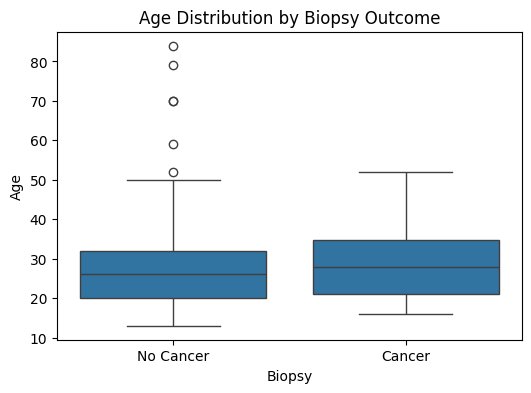

In [18]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Biopsy",
    y="Age",
    data=df_cervical_clean
)

plt.xticks([0,1], ["No Cancer","Cancer"])
plt.title("Age Distribution by Biopsy Outcome")
plt.show()

**Interpretation**

- Patients with **positive biopsy** outcomes tend to show **slightly higher age** values.

- However, the overlap between groups is large, suggesting <u>age alone does not strongly predict cancer outcome</u>.

#### [Dataset 3] | *3- Sexual Partners vs Biopsy Outcome*

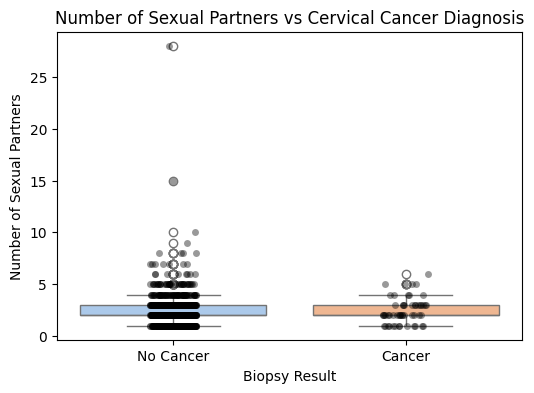

In [24]:
plt.figure(figsize=(6,4))

# Boxplot for distribution summary
sns.boxplot(
    x="Biopsy",
    y="Number of sexual partners",
    data=df_cervical_clean,
    palette="pastel",
    hue="Biopsy",
    legend=False
)

# Overlay individual data points
sns.stripplot(
    x="Biopsy",
    y="Number of sexual partners",
    data=df_cervical_clean,
    color="black",
    alpha=0.4,
    jitter=True
)

plt.xticks([0,1], ["No Cancer","Cancer"])
plt.title("Number of Sexual Partners vs Cervical Cancer Diagnosis")
plt.xlabel("Biopsy Result")
plt.ylabel("Number of Sexual Partners")

plt.show()

**Interpretation**

- The distributions of number of sexual partners for cancer and non-cancer groups **overlap substantially**.

- Most observations in both groups fall within similar ranges, indicating **no clear separation between the categories**.

- A few higher values appear among cancer cases, but these are not frequent enough to show a strong pattern.

- This suggests the **number of sexual partners alone** is **not a strong predictor** of cervical cancer in this dataset.

- Other factors such as HPV infection, screening frequency, and immune response may act as confounding variables influencing the diagnosis.

#### [Dataset 3] | *4- STD Indicators Correlation*

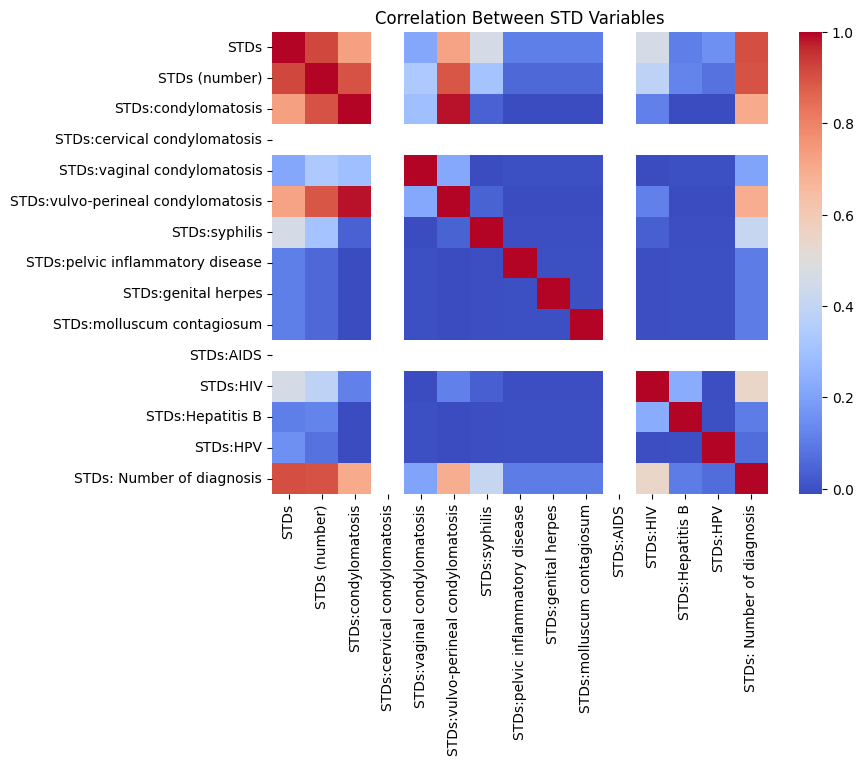

In [25]:
std_cols = [col for col in df_cervical_clean.columns if "STDs" in col]

plt.figure(figsize=(8,6))
sns.heatmap(df_cervical_clean[std_cols].corr(), cmap="coolwarm")
plt.title("Correlation Between STD Variables")
plt.show()

**Interpretation**

- Some STD variables show moderate correlations with each other.

This suggests **possible redundancy between STD indicators**, meaning several variables may represent **similar health conditions**.

Possible confounding variables include:

- healthcare access

- screening frequency

- sexual behavior patterns

#### [Dataset 3] | *5- Smoking vs Cancer Diagnosis*

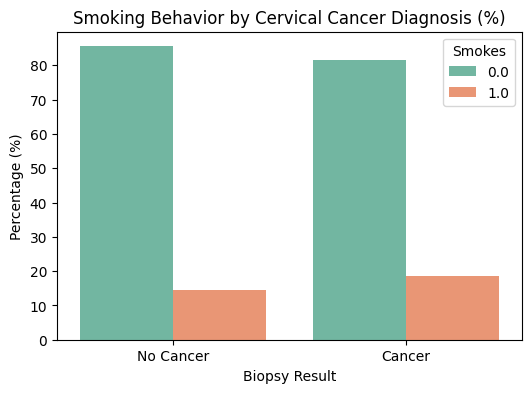

In [27]:
# Calculate percentages within each biopsy category

smoking_pct = (
    df_cervical_clean
    .groupby("Biopsy")["Smokes"]
    .value_counts(normalize=True)
    .rename("percentage")
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=smoking_pct,
    x="Biopsy",
    y="percentage",
    hue="Smokes",
    palette="Set2"
)

plt.xticks([0,1], ["No Cancer","Cancer"])
plt.ylabel("Percentage (%)")
plt.xlabel("Biopsy Result")
plt.title("Smoking Behavior by Cervical Cancer Diagnosis (%)")

plt.legend(title="Smokes")

plt.show()

**Interpretation**

- Smoking appears slightly more common among patients with **positive biopsy results**.

- Smoking is known to **weaken immune response**, which may increase susceptibility to HPV-related cancer development.

- However, the number of positive cases is small, making interpretation cautious.

#### [Dataset 3] | *6- Number of Pregnancies vs Cancer Diagnosis*

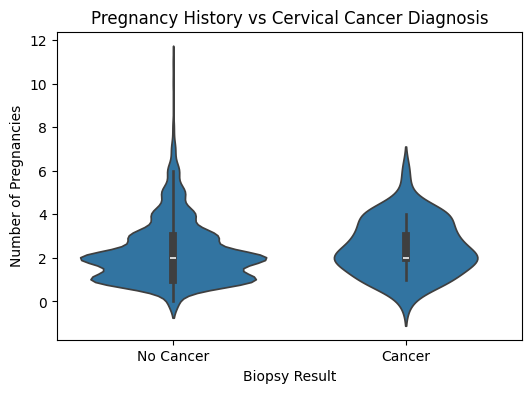

In [28]:
plt.figure(figsize=(6,4))

sns.violinplot(
    x="Biopsy",
    y="Num of pregnancies",
    data=df_cervical_clean
)

plt.xticks([0,1], ["No Cancer","Cancer"])
plt.title("Pregnancy History vs Cervical Cancer Diagnosis")
plt.xlabel("Biopsy Result")
plt.ylabel("Number of Pregnancies")

plt.show()

**Interpretation**

- Patients with cancer diagnoses show slightly **higher pregnancy counts on average**.

- Epidemiological studies suggest that **multiple pregnancies** may increase cervical cancer risk, possibly due to hormonal or immune factors.

- However, other factors such as HPV infection and healthcare access may confound this relationship.

#### [Dataset 3] | *7- CONCLUSIONS*



- **Are the data what you expect? Are the data usable?**

    The cervical cancer dataset reflects several patterns consistent with medical research. Behavioral factors such as smoking, number of sexual partners, and reproductive history show variation across the population and may contribute to cervical cancer risk. Although the dataset contains substantial missing data that required preprocessing, it remains usable for exploratory analysis of risk factors.

- **Do you see any outliers?**

    Some individuals report unusually high numbers of sexual partners or pregnancies. While these values appear extreme relative to most observations, they are plausible behavioral variations rather than clear data errors.

- **Are any data items highly correlated or redundant?**

    Several STD-related variables show moderate correlations with each other, suggesting that some variables may represent overlapping medical conditions. These correlations indicate potential redundancy among certain indicators of sexually transmitted infections.

- **Do you see any trends over time?**

    The dataset does not include time-based variables, so it is not possible to evaluate trends or data drift over time.

- **Possible confounding variables**

    Persistent HPV infection is a major confounding variable that may explain relationships between sexual behavior variables and cervical cancer diagnosis. Additional factors such as healthcare access, screening frequency, and immune system health may also influence the observed relationships.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.